In [18]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to gold layer
con = duckdb.connect('../data/gold/gold.duckdb')

# Style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print("Connected ✓")

Connected ✓


In [19]:
    # ── KPI 1: Overall Default Rate ──────────────────────────────────────────────
kpi = con.execute("""
        SELECT
            COUNT(*) AS total_loans,
            SUM(default_flag) AS total_defaults,
            ROUND(AVG(default_flag) * 100, 2) AS default_rate_pct,
            ROUND(SUM(funded_amnt) / 1e9, 2) AS total_funded_bn,
            ROUND(AVG(funded_amnt), 2) AS avg_loan_amount,
            ROUND(AVG(int_rate), 2) AS avg_interest_rate
        FROM fact_loans
    """).fetchdf()

print("=== OVERALL KPIs ===")
print(kpi.to_string(index=False))

=== OVERALL KPIs ===
 total_loans  total_defaults  default_rate_pct  total_funded_bn  avg_loan_amount  avg_interest_rate
     1246701        264485.0             21.21            18.16         14562.95               0.13


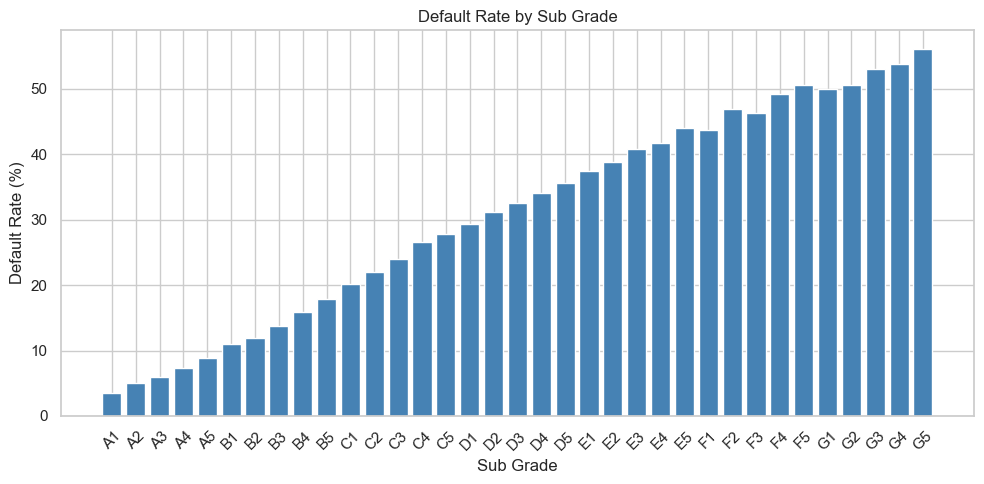

sub_grade  total_loans  default_rate_pct  avg_int_rate
       A1        40935              3.46          0.06
       A2        34063              5.00          0.07
       A3        34377              5.92          0.07
       A4        46695              7.33          0.07
       A5        58913              8.88          0.08
       B1        65912             11.05          0.09
       B2        68425             11.97          0.10
       B3        74294             13.79          0.11
       B4        77156             15.83          0.11
       B5        76009             17.93          0.12
       C1        79438             20.17          0.13
       C2        73013             22.05          0.13
       C3        70710             23.96          0.14
       C4        70570             26.64          0.15
       C5        64049             27.88          0.16
       D1        47811             29.31          0.16
       D2        41409             31.25          0.17
       D3 

In [20]:
# ── KPI 2: Default Rate by Sub Grade ──────────────────────────────────────────────
by_grade = con.execute("""
    SELECT
        dr.sub_grade,
        COUNT(*) AS total_loans,
        ROUND(AVG(f.default_flag) * 100, 2) AS default_rate_pct,
        ROUND(AVG(f.int_rate), 2) AS avg_int_rate
    FROM fact_loans f
    JOIN dim_risk dr ON f.risk_key = dr.risk_key
    GROUP BY dr.sub_grade
    ORDER BY dr.sub_grade
""").fetchdf()

# Plot
fig, ax = plt.subplots()
ax.bar(by_grade['sub_grade'], by_grade['default_rate_pct'], color='steelblue')
ax.set_xlabel('Sub Grade')
ax.set_ylabel('Default Rate (%)')
ax.set_title('Default Rate by Sub Grade')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(by_grade.to_string(index=False))

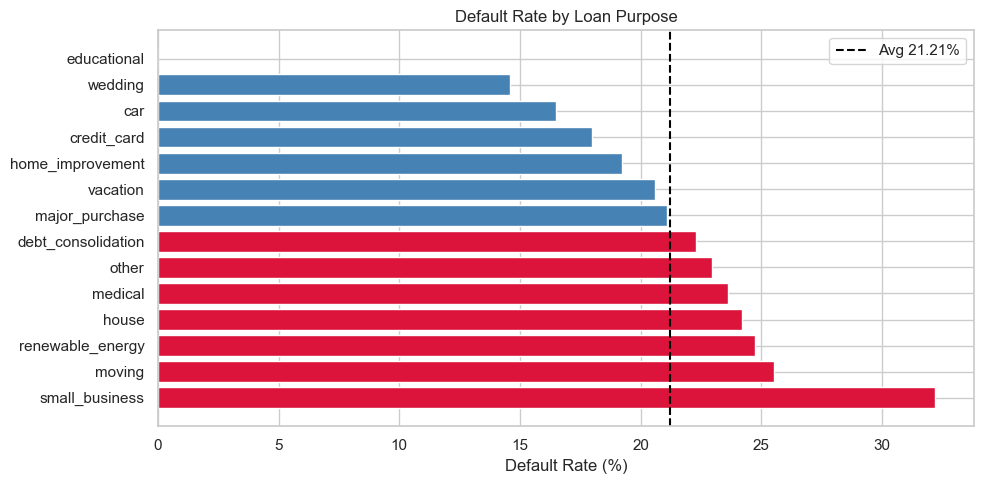

           purpose  total_loans  default_rate_pct  avg_loan_amount
    small_business        12463             32.20         15988.14
            moving         8620             25.51          7982.59
  renewable_energy          788             24.75         10196.57
             house         6618             24.22         15563.05
           medical        14415             23.62          9078.91
             other        71587             22.95         10011.10
debt_consolidation       726299             22.28         15343.34
    major_purchase        26343             21.09         12352.23
          vacation         8406             20.59          6247.23
  home_improvement        81046             19.24         14332.34
       credit_card       276886             17.98         14887.75
               car        12352             16.49          9232.45
           wedding          877             14.60         10733.12
       educational            1              0.00          220

In [21]:
# ── KPI 3: Default Rate by Purpose ──────────────────────────────────────────────
by_purpose = con.execute("""
    SELECT
        dp.purpose,
        COUNT(*) AS total_loans,
        ROUND(AVG(f.default_flag) * 100, 2) AS default_rate_pct,
        ROUND(AVG(f.funded_amnt), 2) AS avg_loan_amount
    FROM fact_loans f
    JOIN dim_purpose dp ON f.purpose_key = dp.purpose_key
    GROUP BY dp.purpose
    ORDER BY default_rate_pct DESC
""").fetchdf()

# Plot
fig, ax = plt.subplots()
colors = ['crimson' if x > 21.21 else 'steelblue' for x in by_purpose['default_rate_pct']]
ax.barh(by_purpose['purpose'], by_purpose['default_rate_pct'], color=colors)
ax.axvline(x=21.21, color='black', linestyle='--', label='Avg 21.21%')
ax.set_xlabel('Default Rate (%)')
ax.set_title('Default Rate by Loan Purpose')
ax.legend()
plt.tight_layout()
plt.show()

print(by_purpose.to_string(index=False))

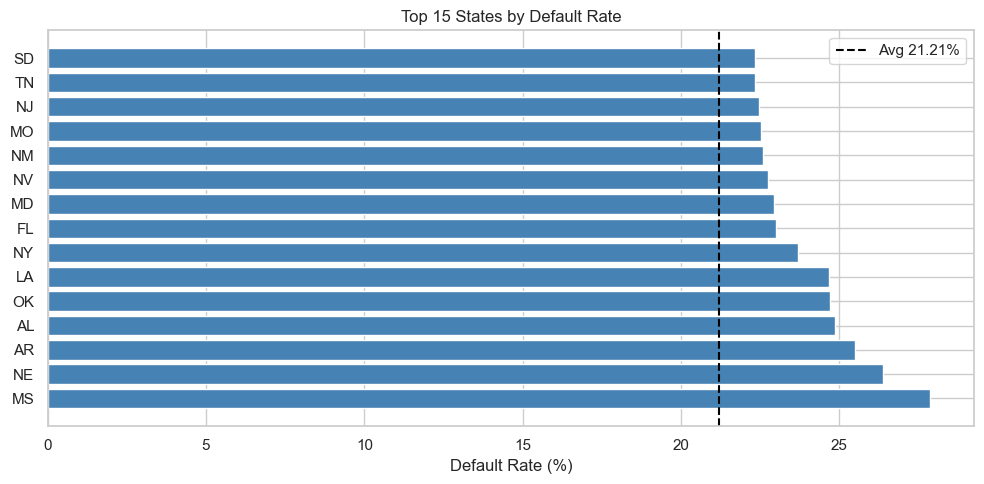

In [22]:
# ── KPI 4: Default Rate by State ──────────────────────────────────────────────
by_state = con.execute("""
    SELECT
        addr_state,
        COUNT(*) AS total_loans,
        ROUND(AVG(default_flag) * 100, 2) AS default_rate_pct
    FROM fact_loans
    GROUP BY addr_state
    HAVING COUNT(0) > 100
    ORDER BY default_rate_pct DESC
    LIMIT 15
""").fetchdf()

# Plot
fig, ax = plt.subplots()
ax.barh(by_state['addr_state'], by_state['default_rate_pct'], color='steelblue')
ax.axvline(x=21.21, color='black', linestyle='--', label='Avg 21.21%')
ax.set_xlabel('Default Rate (%)')
ax.set_title('Top 15 States by Default Rate')
ax.legend()
plt.tight_layout()
plt.show()

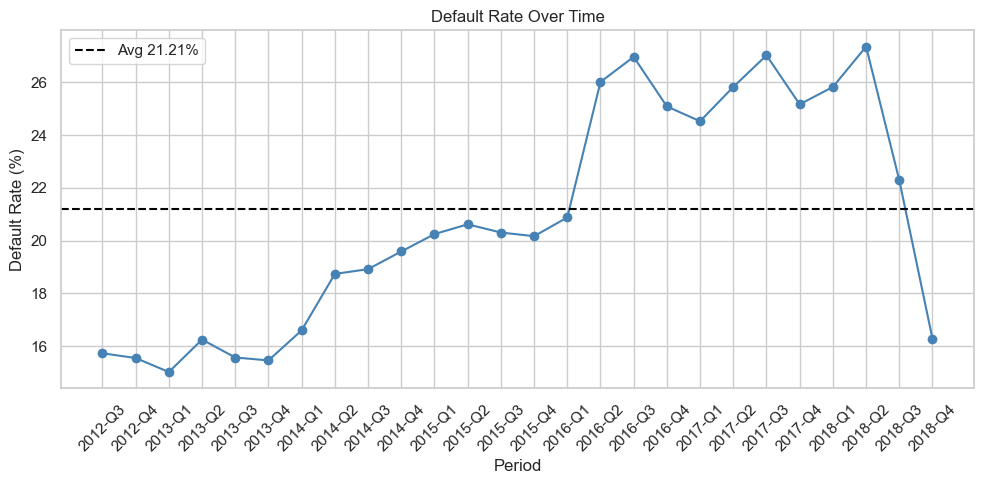

In [23]:
# ── KPI 5: Default Rate Over Time ──────────────────────────────────────────────
by_time = con.execute("""
    SELECT
        dd.year,
        dd.quarter,
        COUNT(*) AS total_loans,
        ROUND(AVG(f.default_flag) * 100, 2) AS default_rate_pct
    FROM fact_loans f
    JOIN dim_date dd ON f.date_key = dd.date_key
    GROUP BY dd.year, dd.quarter
    ORDER BY dd.year, dd.quarter
""").fetchdf()

by_time['period'] = by_time['year'].astype(str) + '-Q' + by_time['quarter'].astype(str)

# Plot
fig, ax = plt.subplots()
ax.plot(by_time['period'], by_time['default_rate_pct'], marker='o', color='steelblue')
ax.axhline(y=21.21, color='black', linestyle='--', label='Avg 21.21%')
ax.set_xlabel('Period')
ax.set_ylabel('Default Rate (%)')
ax.set_title('Default Rate Over Time')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

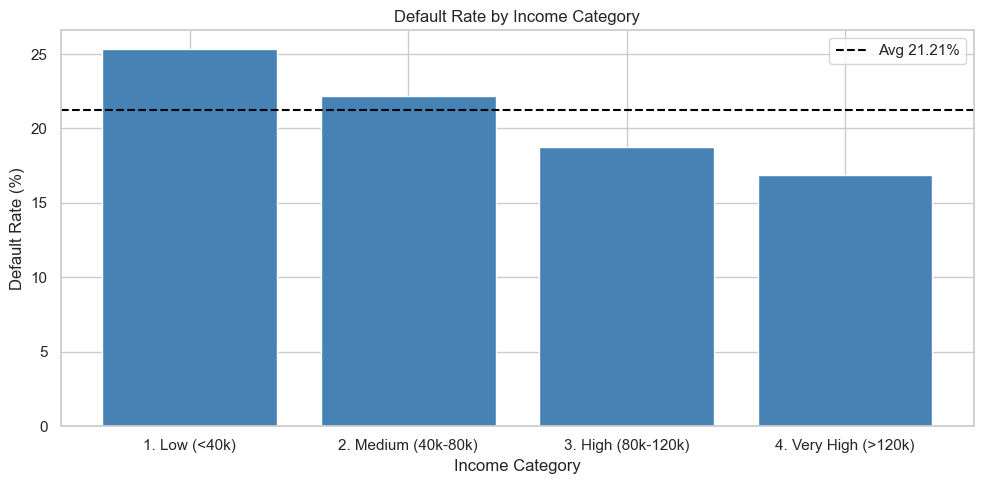

     income_category  total_loans  default_rate_pct  avg_dti
       1. Low (<40k)       192282             25.32    20.61
 2. Medium (40k-80k)       615389             22.17    19.17
  3. High (80k-120k)       281564             18.77    17.04
4. Very High (>120k)       157466             16.84    14.22


In [24]:
# ── KPI 6: Default Rate by Income Category ──────────────────────────────────────────────
by_income = con.execute("""
    SELECT
        CASE 
            WHEN annual_inc < 40000 THEN '1. Low (<40k)'
            WHEN annual_inc < 80000 THEN '2. Medium (40k-80k)'
            WHEN annual_inc < 120000 THEN '3. High (80k-120k)'
            ELSE '4. Very High (>120k)'
        END AS income_category,
        COUNT(*) AS total_loans,
        ROUND(AVG(default_flag) * 100, 2) AS default_rate_pct,
        ROUND(AVG(dti), 2) AS avg_dti
    FROM fact_loans
    GROUP BY income_category
    ORDER BY income_category
""").fetchdf()

fig, ax = plt.subplots()
ax.bar(by_income['income_category'], by_income['default_rate_pct'], color='steelblue')
ax.axhline(y=21.21, color='black', linestyle='--', label='Avg 21.21%')
ax.set_xlabel('Income Category')
ax.set_ylabel('Default Rate (%)')
ax.set_title('Default Rate by Income Category')
ax.legend()
plt.tight_layout()
plt.show()

print(by_income.to_string(index=False))

In [25]:
# ── Verification Status vs Risk Profile ──────────────────────────────────────────────
verification = con.execute("""
    SELECT
        verification_status,
        COUNT(*) AS total_loans,
        ROUND(AVG(default_flag) * 100, 2) AS default_rate_pct,
        ROUND(AVG(fico_range_low), 2) AS avg_fico,
        ROUND(AVG(annual_inc), 2) AS avg_income,
        ROUND(AVG(dti), 2) AS avg_dti
    FROM fact_loans
    GROUP BY verification_status
    ORDER BY default_rate_pct DESC
""").fetchdf()

print(verification.to_string(index=False))

verification_status  total_loans  default_rate_pct  avg_fico  avg_income  avg_dti
           Verified       374500             25.01    692.44    75853.11    19.69
    Source Verified       503547             22.39    692.60    79413.65    17.60
       Not Verified       368654             15.75    704.01    70750.13    17.80


In [26]:
con.close()
print("Analysis complete ✓")

Analysis complete ✓
